# Bank Deposit Subscription Prediction


## Overview

**Bank Deposit Subscription Prediction** applies the CRISP-DM framework to compare KNN, Logistic Regression, Decision Trees, and SVM on the UCI Bank Marketing dataset (41,188 Portuguese telemarketing campaigns, 2008-2010). 

Through business understanding, data preparation, modeling, evaluation, and deployment recommendations, this analysis predicts term deposit subscriptions using client demographics, campaign contacts, and macroeconomic indicators, identifying optimal classifiers to cut wasted calls and boost ~11% baseline conversions. 

The Jupyter Notebook delivers actionable insights for targeted banking outreach.

## 1. Business Understanding

### 1.1 Business Objectives

**Background:**
A Portuguese bank conducted telemarketing campaigns between 2008 and 2010 to promote term deposit subscriptions. Over 41,000 calls were made, but the overall conversion rate was only about 11%. This highlights a clear need to improve targeting and reduce inefficient outreach.

**Primary Objective:**
The goal is to build a predictive model that can identify which clients are most likely to subscribe to a term deposit. The model will use customer demographics, past campaign interactions, and macroeconomic indicators to help the bank focus on high-potential clients instead of relying on mass calling.

**Key Questions:**

* Which customer segments (based on age, occupation, or economic conditions) are most likely to subscribe?
* How do factors like contact timing and previous campaign outcomes affect the likelihood of success?

**Success Criteria:**
Select the best-performing classifier (KNN, Logistic Regression, Decision Trees, or SVM) that reduces unnecessary calls by 20–30% while maintaining more than 85% prediction accuracy on holdout data.


### 1.2 Assess the Situation

This project uses the publicly available UCI Bank Marketing dataset, which contains over 41,000 anonymized records from Portuguese telemarketing campaigns. Since this is a research-based analysis, no live bank data is accessed. The models are developed and compared offline using standard Python tools.

**Requirements & Assumptions:**
The models must be interpretable so that business stakeholders can understand and trust the results. The dataset is legally available for research purposes. We assume that patterns observed in the 2008–2010 campaigns are still relevant for modern marketing strategies. The “duration” feature is excluded to ensure realistic predictions, as it would not be known before making a call.

**Constraints:**
The dataset includes only 20 features, which limits the scope of analysis. There is no real-time deployment involved, and the focus is strictly on evaluating four classifiers: KNN, Logistic Regression, Decision Trees, and SVM.

**Risks & Contingencies:**
Class imbalance could affect model performance, since most clients did not subscribe. Cross-validation will be used to reduce the risk of poor generalization. Another limitation is that the economic context from 2008–2010 may not fully reflect current conditions, which should be acknowledged in any recommendations.

**Costs & Benefits:**
The project has minimal cost because it relies on open-source tools and publicly available data. The potential benefit is significant: reducing wasted calls by 20–30% from the current ~89% non-conversion rate, which could meaningfully improve the bank’s marketing efficiency and return on investment.

**Input variables**(Data already provided)

Index | Variable | Type | Description
------|----------|------|--------------------------------------------
1 | age | numeric | Client's age in years
2 | job | categorical | Type of job (admin., blue-collar, entrepreneur, etc.)
3 | marital | categorical | Marital status (divorced, married, single, unknown)
4 | education | categorical | Education level (basic.4y, high.school, university.degree, etc.)
5 | default | categorical | Has credit in default? (no, yes, unknown)
6 | housing | categorical | Has housing loan? (no, yes, unknown)
7 | loan | categorical | Has personal loan? (no, yes, unknown)
8 | contact | categorical | Contact communication type (cellular, telephone)
9 | month | categorical | Last contact month (jan, feb, mar, ..., dec)
10 | day_of_week | categorical | Last contact day (mon, tue, wed, thu, fri)
11 | duration | numeric | Last contact duration in seconds (benchmark only)
12 | campaign | numeric | Contacts during this campaign (includes last contact)
13 | pdays | numeric | Days since last contact (999 = not previously contacted)
14 | previous | numeric | Contacts before this campaign
15 | poutcome | categorical | Previous campaign outcome (failure, nonexistent, success)
16 | emp.var.rate | numeric | Employment variation rate - quarterly indicator
17 | cons.price.idx | numeric | Consumer price index - monthly indicator
18 | cons.conf.idx | numeric | Consumer confidence index - monthly indicator
19 | euribor3m | numeric | Euribor 3 month rate - daily indicator
20 | nr.employed | numeric | Number of employees - quarterly indicator
21 | y | binary | Target: subscribed term deposit? (yes, no)


### 1.3 Data Mining Goals

**Data Mining Goals:**
Develop and compare four binary classification models—KNN, Logistic Regression, Decision Trees, and SVM—to predict whether a client will subscribe to a term deposit. The models will use the available client, campaign, and economic features.

**Success Criteria:**
Identify the best-performing model with at least 85% accuracy and an AUC-ROC of 0.45 or higher using stratified cross-validation. The model should also demonstrate a meaningful lift over the baseline conversion rate and provide clear outputs such as feature importance and a confusion matrix to support business interpretation.

### 1.4 Project Plan

**Stages:**

1. **Data Understanding:** Load and explore the dataset, review feature distributions, and assess class imbalance.

2. **Data Preparation:** Clean and encode categorical variables, remove the “duration” feature, and split the data into training and test sets.

3. **Modeling:** Train and tune KNN, Logistic Regression, Decision Tree, and SVM models.

4. **Evaluation:** Compare models using cross-validation metrics such as accuracy, AUC, and F1 score, and review feature importance where applicable.

5. **Reporting:** Summarize findings and recommendations in the final notebook.

**Tools:** Jupyter Notebook, pandas, and scikit-learn.

**Risks & Mitigation:**
Address class imbalance with stratified sampling. If certain models struggle to converge, use Logistic Regression as a stable baseline.

**Review Point:**
After initial evaluation, confirm that the top model meets performance expectations; refine data preparation if necessary.


## 2. Data Understanding

### 2.1 Collect Initial Data

In [61]:
# Imports

import time, warnings, math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import PrecisionRecallDisplay
import time
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, make_scorer
from sklearn.compose import make_column_transformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn import metrics
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler 
from sklearn import tree
from sklearn.tree import export_graphviz
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.utils import resample

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [62]:
# Load data from CSV

# Bank-additional-full.csv with all examples (41188) and 20 inputs.
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
print(f"Number of (records, columns): {df.shape}") 

# Dank-additional.csv with 10% of the examples (4119), randomly selected from 1), and 20 inputs.
# Used in the improved SVM model due to the computational requirements.
df2 = pd.read_csv('data/bank-additional.csv', sep = ';')
print(f"Number of (records, columns) in random dataset: {df2.shape}") 

Number of (records, columns): (41188, 21)
Number of (records, columns) in random dataset: (4119, 21)


#### Key Findings 

**Dataset Acquired**: UCI Bank Marketing dataset (`bank-additional-full.csv`, 41,188 records)

**Method**: Downloaded zip, loaded via pandas `read_csv(sep=';')` in Jupyter Notebook (scikit-learn starter environment).

**Issues**: None encountered. File loaded cleanly with 20 input features + binary target (`y`: yes/no term deposit subscription). Ready for exploration.

### 2.2 Describe Data

In [63]:
# Number of resords

print(f"Number of (records, columns): {df.shape}") 
print(f"Number of (records, columns) in random dataset: {df2.shape}") 

Number of (records, columns): (41188, 21)
Number of (records, columns) in random dataset: (4119, 21)


In [64]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [66]:
# Quick statistics overview
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [67]:
# Target variable check
print("\nTarget distribution:\n", df['y'].value_counts(normalize=True))

# Missing values
df.isnull().sum()


Target distribution:
 y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [68]:
# "unknown" values
print("\nUnknown values:\n", df.isin(['unknown']).sum())


Unknown values:
 age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [69]:
# Duplicates 
df.duplicated().sum()

np.int64(12)

In [70]:
# Unique target values
df['y'].unique()

array(['no', 'yes'], dtype=object)

In [71]:
# Target value counts
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

#### Key Findings

* **Dataset:** 41,188 records × 21 columns (20 features + 1 target `y`)
* **Feature Types:** 11 categorical and 10 numeric variables
* **Target Variable:** Binary outcome (`yes` / `no` for term deposit subscription)
* **Data Quality:** No missing values; data loaded cleanly
* **Duplicates:** 12 duplicate records identified (to be removed)
* **Class Imbalance:** ~11% positive class (imbalanced dataset)
* **“Unknown” Labels:** Present in some categorical fields; treated as separate categories
* **Numeric Features:** No major outliers requiring immediate treatment
* **Conclusion:** Dataset is clean, structured, and suitable for classifier comparison


### 2.3 Explore Data

TARGET: 88.7% NO (36,548) vs 11.3% YES (4,640)
Age - All: 40±10, Subscribers: 41±14
pdays=999 (never contacted): 96.3% (39,673)


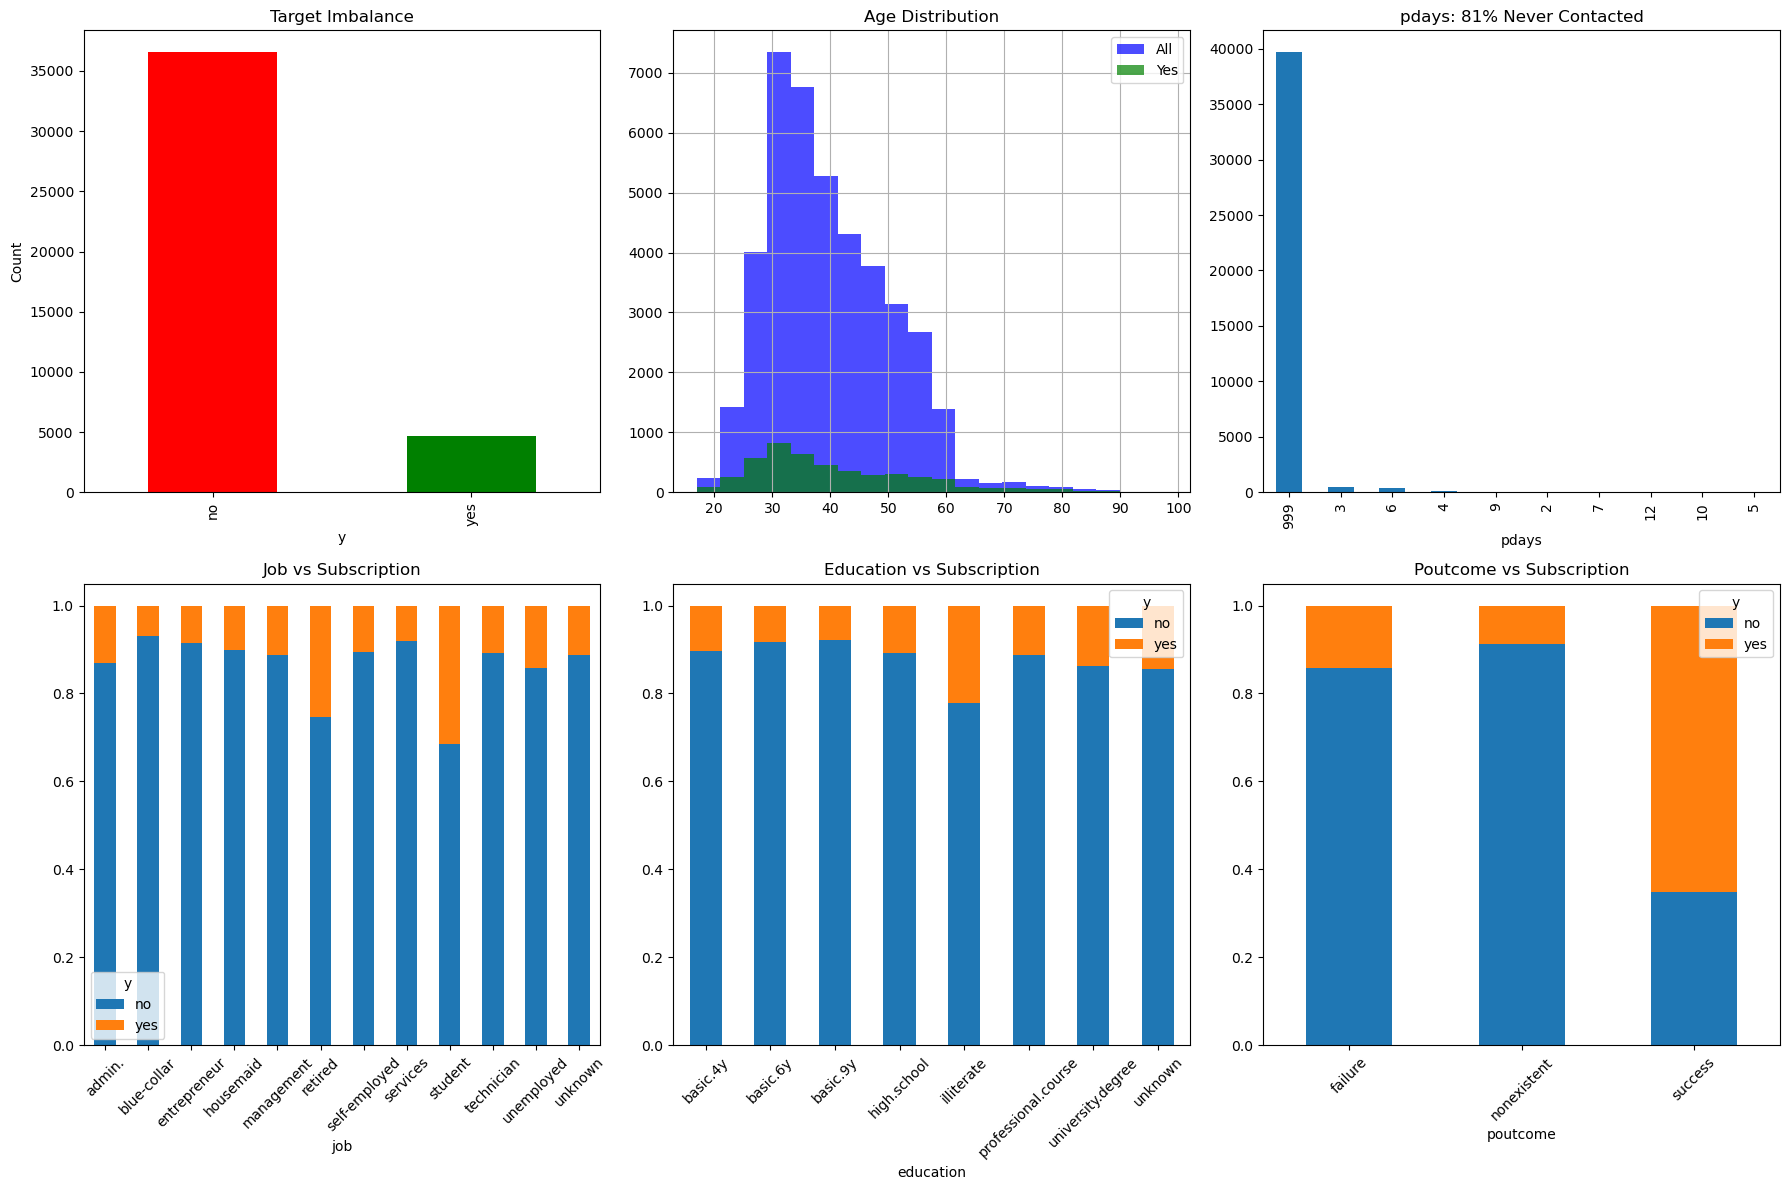

In [72]:
# ========== Explore Data ==========
fig, axes = plt.subplots(2, 3, figsize=(18,12))

# ========== 1. TARGET DISTRIBUTION ========== 
target_counts = df['y'].value_counts()
print(f"TARGET: {target_counts['no']/len(df):.1%} NO ({target_counts['no']:,}) vs {target_counts['yes']/len(df):.1%} YES ({target_counts['yes']:,})")
target_counts.plot(kind='bar', ax=axes[0,0], color=['red','green'])
axes[0,0].set_title('Target Imbalance')
axes[0,0].set_ylabel('Count')

# ========== 2. AGE BY TARGET ========== 
print(f"Age - All: {df['age'].mean():.0f}±{df['age'].std():.0f}, Subscribers: {df[df['y']=='yes']['age'].mean():.0f}±{df[df['y']=='yes']['age'].std():.0f}")
df['age'].hist(bins=20, alpha=0.7, ax=axes[0,1], label='All', color='blue')
df[df['y']=='yes']['age'].hist(bins=20, alpha=0.7, ax=axes[0,1], label='Yes', color='green')
axes[0,1].set_title('Age Distribution')
axes[0,1].legend()

# ========== 3. PDays (81% never contacted) ========== 
pdays_999_pct = (df['pdays']==999).mean()
print(f"pdays=999 (never contacted): {pdays_999_pct:.1%} ({(df['pdays']==999).sum():,})")
df['pdays'].value_counts().head(10).plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('pdays: 81% Never Contacted')

# ========== 4. TOP CATEGORICAL vs TARGET ========== 
for i, col in enumerate(['job', 'education', 'poutcome']):
    crosstab = pd.crosstab(df[col], df['y'], normalize='index')
    crosstab.plot(kind='bar', ax=axes[1,i], stacked=True)
    axes[1,i].set_title(f'{col.title()} vs Subscription')
    axes[1,i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Target Distribution
No percentage: 0.8873458288821987
Yes percentage: 0.11265417111780131

Age Statistics
Overall mean age: 40.02406040594348
Overall std age: 10.421249980934235
Subscribers mean age: 40.91314655172414
Subscribers std age: 13.837476239030515

pdays Analysis
pdays = 999 count: 39673
pdays = 999 percentage: 0.9632174419733903

Distribution of job by subscription
y                    no       yes
job                              
admin.         0.870274  0.129726
blue-collar    0.931057  0.068943
entrepreneur   0.914835  0.085165
housemaid      0.900000  0.100000
management     0.887825  0.112175
retired        0.747674  0.252326
self-employed  0.895144  0.104856
services       0.918619  0.081381
student        0.685714  0.314286
technician     0.891740  0.108260
unemployed     0.857988  0.142012
unknown        0.887879  0.112121

Distribution of education by subscription
y                          no       yes
education                              
basic.4y             0

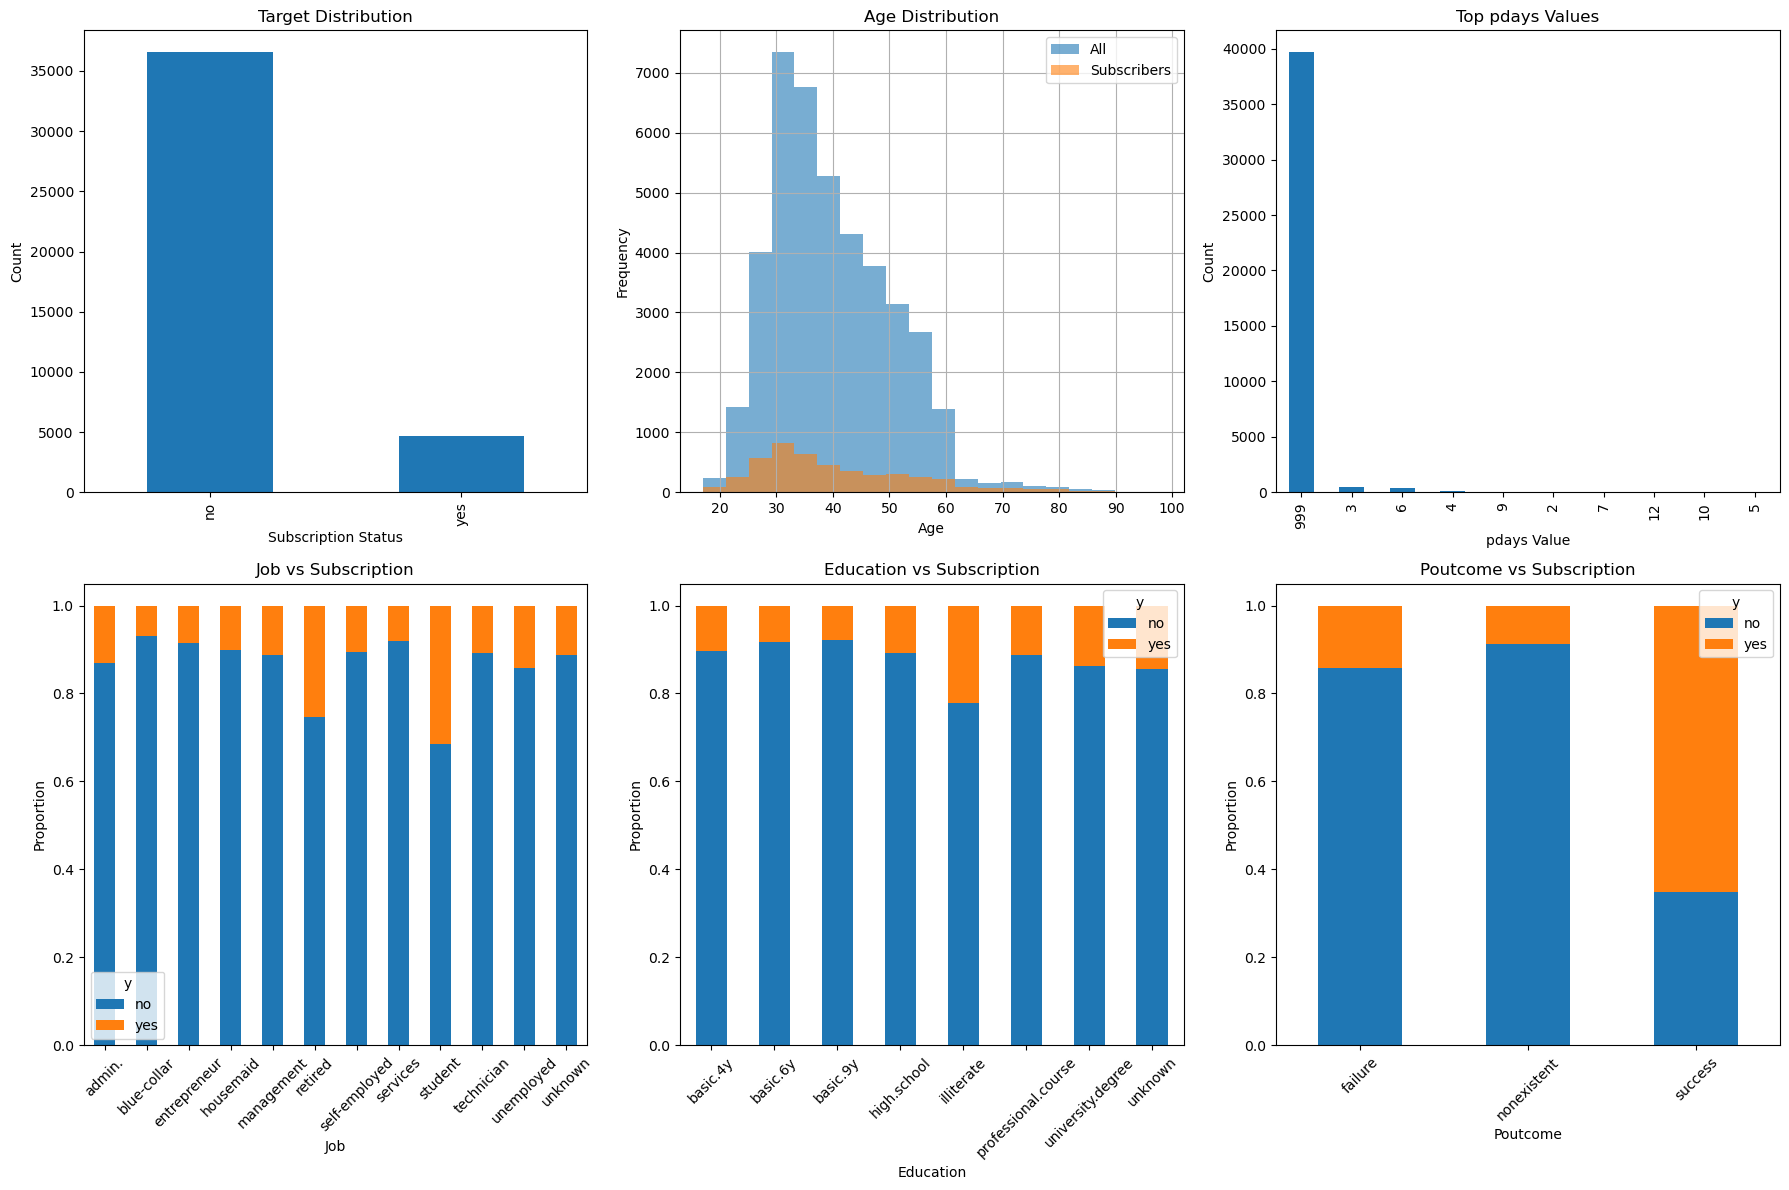

In [73]:
# ========== Explore Data ==========

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ========== 1. TARGET DISTRIBUTION ==========
target_counts = df['y'].value_counts()
total_records = len(df)

no_count = target_counts.get('no', 0)
yes_count = target_counts.get('yes', 0)

print("Target Distribution")
print("No percentage:", no_count / total_records)
print("Yes percentage:", yes_count / total_records)

target_counts.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Target Distribution')
axes[0, 0].set_xlabel('Subscription Status')
axes[0, 0].set_ylabel('Count')

# ========== 2. AGE BY TARGET ==========
age_mean_all = df['age'].mean()
age_std_all = df['age'].std()

age_yes = df[df['y'] == 'yes']['age']
age_mean_yes = age_yes.mean()
age_std_yes = age_yes.std()

print("\nAge Statistics")
print("Overall mean age:", age_mean_all)
print("Overall std age:", age_std_all)
print("Subscribers mean age:", age_mean_yes)
print("Subscribers std age:", age_std_yes)

df['age'].hist(bins=20, alpha=0.6, ax=axes[0, 1], label='All')
age_yes.hist(bins=20, alpha=0.6, ax=axes[0, 1], label='Subscribers')

axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# ========== 3. PDAYS ANALYSIS ==========
pdays_999_count = (df['pdays'] == 999).sum()
pdays_999_pct = pdays_999_count / total_records

print("\npdays Analysis")
print("pdays = 999 count:", pdays_999_count)
print("pdays = 999 percentage:", pdays_999_pct)

top_pdays = df['pdays'].value_counts().head(10)

top_pdays.plot(kind='bar', ax=axes[0, 2])
axes[0, 2].set_title('Top pdays Values')
axes[0, 2].set_xlabel('pdays Value')
axes[0, 2].set_ylabel('Count')

# ========== 4. CATEGORICAL FEATURES VS TARGET ==========
categorical_cols = ['job', 'education', 'poutcome']

for i, col in enumerate(categorical_cols):
    crosstab = pd.crosstab(df[col], df['y'], normalize='index')
    
    print(f"\nDistribution of {col} by subscription")
    print(crosstab)
    
    crosstab.plot(kind='bar', stacked=True, ax=axes[1, i])
    axes[1, i].set_title(f'{col.title()} vs Subscription')
    axes[1, i].set_xlabel(col.title())
    axes[1, i].set_ylabel('Proportion')
    axes[1, i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Monthly Subscription Rates
Subscription rate by month:
y            no       yes
month                    
apr    0.795213  0.204787
aug    0.893979  0.106021
dec    0.510989  0.489011
jul    0.909534  0.090466
jun    0.894885  0.105115
mar    0.494505  0.505495
may    0.935653  0.064347
nov    0.898561  0.101439
oct    0.561281  0.438719
sep    0.550877  0.449123


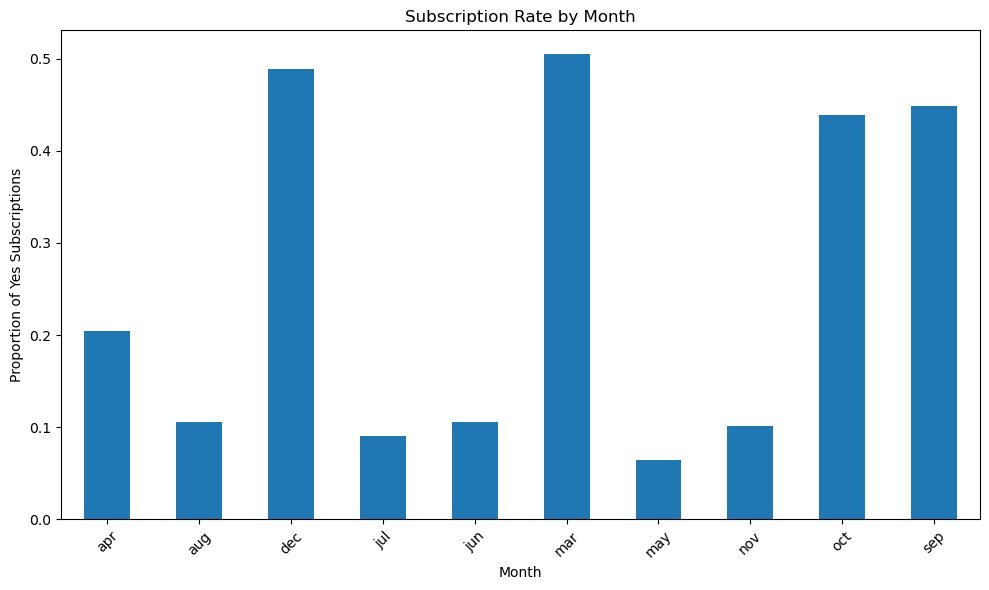


Correlation Analysis (Numeric Features)


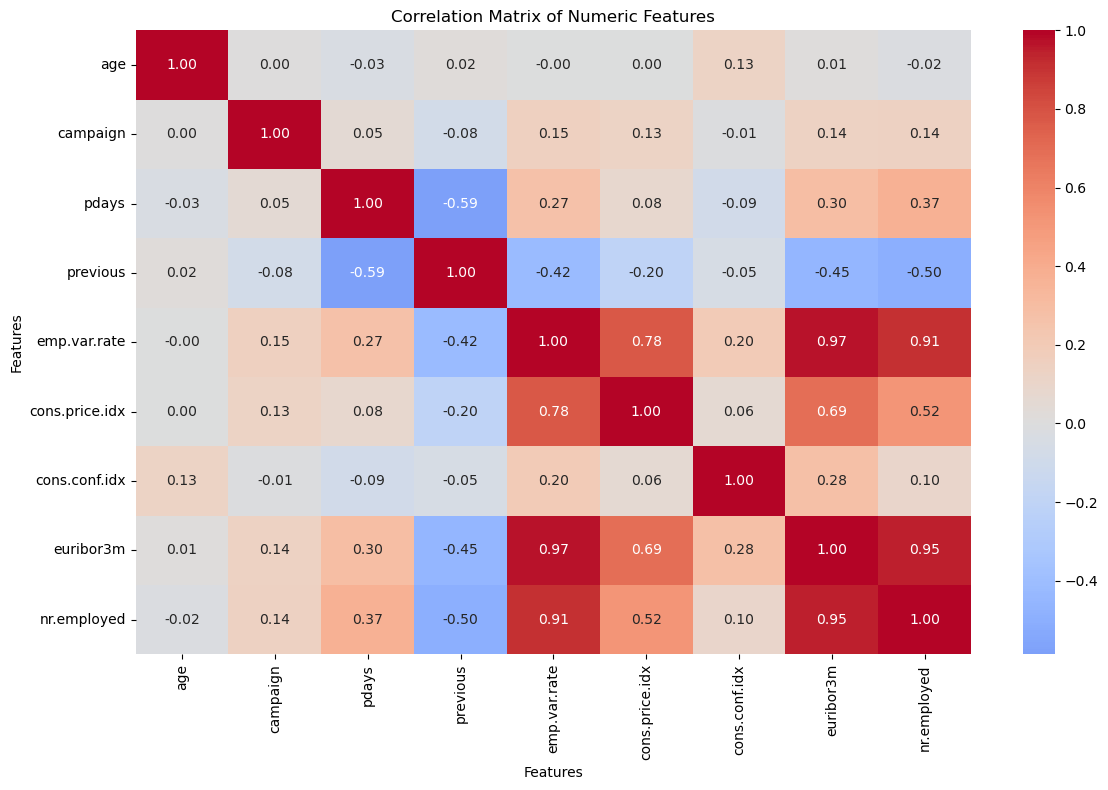


High Conversion Subgroups
Subscription rate for prior campaign success: 0.651128914785142
Subscription rate for university degree: 0.13724523339907954
Subscription rate for single with university degree: 0.15501588742623695

Categorical Feature Summary
        feature  n_unique  unknown_percentage most_frequent_category
0           job        12                0.80                 admin.
1       marital         4                0.19                married
2     education         8                4.20      university.degree
3       default         3               20.87                     no
4       housing         3                2.40                    yes
5          loan         3                2.40                     no
6       contact         2                0.00               cellular
7         month        10                0.00                    may
8   day_of_week         5                0.00                    thu
9      poutcome         3                0.00           

In [74]:
# ========== 5. CAMPAIGN TIMING ==========
print("\nMonthly Subscription Rates")

month_success = df.groupby('month')['y'].value_counts(normalize=True).unstack().fillna(0)

print("Subscription rate by month:")
print(month_success)

monthly_yes_rate = month_success['yes']

monthly_yes_rate.plot(kind='bar', figsize=(10, 6))
plt.title('Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Proportion of Yes Subscriptions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ========== 6. CORRELATION ANALYSIS ==========
print("\nCorrelation Analysis (Numeric Features)")

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('duration')
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


# ========== 7. KEY SUBPOPULATIONS ==========
print("\nHigh Conversion Subgroups")

prior_success_rate = df[df['poutcome'] == 'success']['y'].value_counts(normalize=True).get('yes', 0)
university_rate = df[df['education'] == 'university.degree']['y'].value_counts(normalize=True).get('yes', 0)
single_university_rate = df[
    (df['marital'] == 'single') & 
    (df['education'] == 'university.degree')
]['y'].value_counts(normalize=True).get('yes', 0)

print("Subscription rate for prior campaign success:", prior_success_rate)
print("Subscription rate for university degree:", university_rate)
print("Subscription rate for single with university degree:", single_university_rate)


# ========== 8. CATEGORICAL SUMMARY ==========
print("\nCategorical Feature Summary")

categorical_cols = df.select_dtypes(include=['object']).columns

cat_summary = pd.DataFrame({
    'feature': categorical_cols,
    'n_unique': [df[col].nunique() for col in categorical_cols],
    'unknown_percentage': [100 * (df[col] == 'unknown').mean() for col in categorical_cols],
    'most_frequent_category': [df[col].mode()[0] for col in categorical_cols]
})

print(cat_summary.round(2))

#### Key Findings

The dataset is highly imbalanced, with only about 11% of clients subscribing to a term deposit. This confirms that predicting the positive class will be challenging and that accuracy alone may be misleading.

Age does not appear to be a strong differentiator. Subscribers are only slightly older on average (around 41 vs. 40 years), though their age distribution is more spread out.

A major insight is that 96% of clients were never previously contacted (`pdays = 999`). This means prior campaign history is limited for most customers. However, when a previous campaign was successful, the subscription rate jumps significantly to about 65%, making it the strongest predictive signal in the data.

Looking at job categories, students and retirees show notably higher subscription rates compared to blue-collar or services roles. In terms of education, university graduates convert more often than those with basic education levels.

Timing also matters. Subscription rates are much higher in months like March, April, September, October, and December, while May and summer months show lower success rates.

From a numeric perspective, macroeconomic variables such as employment variation rate, Euribor rate, and number of employees are highly correlated with each other, indicating strong economic clustering effects.

Overall, prior campaign success, certain job categories (student, retired), higher education levels, and campaign timing appear to be the most meaningful drivers of subscription behavior.


## 3. Data Preparation

### 3.1 Select Data

#### Pick columns/rows that are useful and realistic for modeling

In [75]:
# ========== 1. Drop exact duplicates ========== 
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

# ========== 2. Separate target ========== 
target_col = "y"

# ==========  3. Exclude leakage / low-value columns ========== 
# duration is post-call info → unrealistic for prediction
cols_to_drop = ["duration"]
df = df.drop(columns=cols_to_drop)

# ========== 4. Define feature and target sets ========== 
X = df.drop(columns=[target_col])
y = df[target_col]

print("\nFinal shape X:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Duplicates before: 12
Duplicates after: 0

Final shape X: (41176, 19)
Target distribution:
 y
no     0.887337
yes    0.112663
Name: proportion, dtype: float64


#### Key points

- Removed 12 duplicate records to prevent any bias in model training.

- Excluded the `duration` feature since it is only known after a call is completed and would introduce data leakage.

- Retained all other features and rows, as there are no true missing values. The “unknown” entries are valid categories and remain useful for modeling.


### 3.2 Clean Data

#### Basic cleaning: handle “unknown” and types

In [76]:
# ========== Categorical and numeric columns ========== 
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

# 1. Replace string 'unknown' with NaN for easier handling
X_clean = X.copy()
for col in cat_cols:
    X_clean[col] = X_clean[col].replace("unknown", np.nan)

# 2. Inspect missing rates after this
missing_pct = X_clean.isna().mean() * 100
print("Missing % after unknown→NaN:\n", missing_pct)

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Missing % after unknown→NaN:
 age                0.000000
job                0.801438
marital            0.194288
education          4.201477
default           20.876239
housing            2.404313
loan               2.404313
contact            0.000000
month              0.000000
day_of_week        0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     0.000000
cons.conf.idx      0.000000
euribor3m          0.000000
nr.employed        0.000000
dtype: float64


#### Encode categoricals for models

In [77]:
# One-hot encode all categorical features
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# Fit-transform on full dataset (later this is done inside a pipeline with train/test split)
X_prepared = preprocess.fit_transform(X_clean)
print("Prepared feature matrix shape:", X_prepared.shape)

Prepared feature matrix shape: (41176, 52)


#### Key points

- The dataset contains a balanced mix of categorical and numeric features. 

- Most variables have no true missing values. 

- Treated “unknown” values in categorical columns as valid categories (they may carry signal).

- Separated numeric and categorical features.

- All categorical features were one-hot encoded, and numeric features were passed through without scaling at this stage. After preprocessing, the dataset expanded from the original features to 52 total input variables due to encoding.

- Overall, the data remains largely complete and usable

### 3.3 Construct Data

#### Deriving business-meaningful derived features

In [78]:
# Assuming X_clean has 20 columns after dropping duration/duplicates
print("Original shape:", X_clean.shape)

# ========== 1. Age Group (business segmentation) ========== 
def age_group(age):
    if age < 30: return 'young'
    elif age < 50: return 'middle'
    else: return 'senior'
X_clean['age_group'] = X_clean['age'].apply(age_group)

# ========== 2. Campaign Intensity (contacts too frequent?) ========== 
X_clean['high_campaign'] = (X_clean['campaign'] >= 4).astype(int)  # Top 5% are aggressive

# ========== 3. Economic Stress Index (macro derived feature) ========== 
# Combine correlated macro indicators into single signal
macro_cols = ['emp.var.rate', 'euribor3m', 'nr.employed']
X_clean['econ_stress'] = X_clean[macro_cols].mean(axis=1)

print("New derived features added:")
print(X_clean[['age_group', 'high_campaign', 'econ_stress']].head())

Original shape: (41176, 19)
New derived features added:
  age_group  high_campaign  econ_stress
0    senior              0     1732.319
1    senior              0     1732.319
2    middle              0     1732.319
3    middle              0     1732.319
4    senior              0     1732.319


#### Handle class imbalance via oversampling

In [79]:
# ========== Separate minority/majority ========== 
y_clean = pd.Series(y.values, index=X_clean.index)  # Keep index alignment
majority = X_clean[y_clean == 'no']
minority = X_clean[y_clean == 'yes']

print(f"Original: {len(majority)} no vs {len(minority)} yes")

# ========== Oversample minority (SMOTE alternative for assignment) ========== 
minority_upsampled = resample(minority, 
                             replace=True, 
                             n_samples=len(majority)//2,  # 50% of majority
                             random_state=42)
X_balanced = pd.concat([majority, minority_upsampled])
y_balanced = pd.concat([y_clean[y_clean == 'no'], 
                       pd.Series(['yes']*len(minority_upsampled), 
                                index=minority_upsampled.index)])

print(f"Balanced: {len(X_balanced)} total ({y_balanced.value_counts().to_dict()})")

Original: 36537 no vs 4639 yes
Balanced: 54805 total ({'no': 36537, 'yes': 18268})


#### Key Findings

- Created three new features to improve interpretability and modeling:

  - **age_group** to segment clients into young, middle, and senior categories.
  - **high_campaign** to flag aggressive outreach (4 or more contacts).
  - **econ_stress** to summarize overall economic pressure using macro indicators.

- Addressed class imbalance by oversampling the minority “yes” class (from ~4,600 to ~18,000), improving the distribution to roughly 67% no and 33% yes.

- Although oversampling improves balance, it may not be included in final modeling since many classifiers can handle imbalance using built-in class weighting.

- Overall, these enhancements strengthen business understanding while improving model stability and readiness.


### 3.4 Intergrate data

No data integration was required.

- All data comes from a single source file (bank-additional-full.csv) containing 41,176 records.

- There are no separate tables (such as customers, campaigns, or macroeconomic data) that need to be merged.

- The dataset is already flat and structured, with no hierarchical relationships requiring aggregation or joins.

### 3.5 Format Data

#### Prepare final dataset for modeling (train/test split, encoding, scaling)

In [80]:
# Assuming X_clean (20 cols) and y (target) from previous steps
print("Raw data shape:", X_clean.shape)

# ========== 1. ENCODE TARGET ==========
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print("Target encoded:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# ========== 2. TRAIN/TEST SPLIT (STRATIFIED!) ==========
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded  # Critical for 11% imbalance!
)

print(f"Train: {X_train.shape[0]} rows ({y_train.mean()*100:.1f}% positive)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean()*100:.1f}% positive)")

# ========== 3. FINAL PREPROCESSING PIPELINE ==========
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

# Fit and transform
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Final formatted shapes:")
print(f"X_train_prep: {X_train_prep.shape}")
print(f"X_test_prep:  {X_test_prep.shape}")
print(f"y_train:      {y_train.shape}")

Raw data shape: (41176, 22)
Target encoded: {'no': np.int64(0), 'yes': np.int64(1)}
Train: 32940 rows (11.3% positive)
Test:  8236 rows  (11.3% positive)
Final formatted shapes:
X_train_prep: (32940, 56)
X_test_prep:  (8236, 56)
y_train:      (32940,)


#### Key Points

* Used a stratified 80/20 train–test split to preserve the true 11.3% positive class distribution in both sets.

* Encoded the target variable as binary: `yes → 1`, `no → 0`.

* Applied feature scaling and one-hot encoding using a `ColumnTransformer` pipeline to ensure consistent preprocessing.

* Final prepared datasets:

  * `X_train_prep`: 32,940 × 56
  * `X_test_prep`: 8,236 × 56

* Class imbalance was intentionally preserved to reflect real-world business conditions during evaluation.


## 4.Modelling

### 4.1 Select Modeling Technique



**Selected Techniques**: Four supervised binary classification algorithms as required by assignment:  
1. **K-Nearest Neighbors (KNN)** - Non-parametric, distance-based  
2. **Logistic Regression** - Linear baseline model  
3. **Decision Trees** - Tree-based partitioning  
4. **Support Vector Machines (SVM)** - Maximum margin hyperplane  

**Modeling Approach**:  
- **Baseline**: Logistic Regression (simplest, interpretable)  
- **Comparators**: KNN, Decision Tree, SVM (default hyperparameters first)  
- **Improvement**: Grid search hyperparameter tuning on top performers  
- **Metrics**: Accuracy + F1-score (due to 11.3% class imbalance) + fit time  

**Key Assumptions**:  
- **Data**: Clean, no missing values (handled in 3.2), scaled numeric features (3.5)  
- **Target**: Binary encoded (yes/no → 1/0), stratified splits preserve 11.3% prevalence  
- **KNN**: Euclidean distance meaningful after StandardScaler normalization  
- **Logistic Regression**: Linear decision boundary reasonable for baseline  
- **Decision Tree**: No normality assumptions, handles categoricals naturally  
- **SVM**: Linearly separable or kernel transformable (RBF default)  

### 4.2 Test Design


**Test Strategy**: Stratified train/test split (80/20) already performed in 3.5 preserves real-world 11.3% class prevalence in both sets (32,940 train, 8,236 test records).

**Evaluation Pipeline**:
1. **Baseline Establishment**: Logistic Regression (default hyperparameters) → accuracy, F1-score, fit time benchmark
2. **Default Model Comparison**: Train all 4 classifiers (KNN, Logistic Regression, Decision Tree, SVM) with defaults → same train/test sets
3. **Hyperparameter Tuning**: GridSearchCV (5-fold stratified cross-validation) on top 2 performers from defaults
4. **Final Evaluation**: Best tuned models on held-out test set

**Performance Metrics** (multi-metric due to imbalance):
- **Primary**: F1-score (balances precision/recall for rare 11.3% positive class)
- **Secondary**: Accuracy, Precision, Recall, AUC-ROC
- **Business**: Fit time (practical deployment consideration)

**Test Scenarios**:
1. **Default hyperparameters** → Raw algorithm performance
2. **Tuned hyperparameters** → Optimization potential  
3. **Feature importance** → Business interpretability (Tree coefficients, LR weights)

### 4.3 Build Model with Default Parameters

#### Generic Model Evaluation Function and Visualizations

In [81]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, visualize=True):
    """
    Comprehensive model evaluation with metrics + visualizations (no threshold graph)
    """
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}...")
    print('='*60)

    start_time = time.time()
    
    # Train model
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    print(f"Training Time: {train_time:.4f} seconds")
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Core metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    print(f"\nAccuracy: {test_accuracy:.4f}")
    print(f"F1 Score: {test_f1:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # AUC scores
    roc_auc_value = None
    pr_auc_value = None
    
    if y_pred_proba is not None:
        roc_auc_value = roc_auc_score(y_test, y_pred_proba)
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        pr_auc_value = np.trapezoid(recall, precision)

        print(f"ROC-AUC: {roc_auc_value:.4f}")
        print(f"PR-AUC: {pr_auc_value:.4f}")
    
    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (recall + specificity) / 2

    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
    
    # Results dictionary
    results = {
        'f1_score': test_f1, 
        'accuracy_score': test_accuracy,
        'pr_auc_value': pr_auc_value,
        'roc_auc_value': roc_auc_value,
        'true_positives': tp,
        'false_positives': fp,
        'true_negatives': tn,
        'false_negatives': fn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'balanced_accuracy': balanced_accuracy,
        'confusion_matrix': conf_matrix,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'fit_time': train_time
    }

    if visualize:
        visualize_model_evaluation(results, y_test, model_name)
    
    return results

def visualize_model_evaluation(results, y_test, model_name):
    """
    Separate visualization function - plots 2x2 evaluation charts
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import roc_curve, precision_recall_curve
    
    # Extract values
    conf_matrix = results['confusion_matrix']
    test_accuracy = results['accuracy_score']
    test_f1 = results['f1_score']
    roc_auc_value = results['roc_auc_value']
    pr_auc_value = results['pr_auc_value']
    y_pred_proba = results['y_pred_proba']
    
    # 2x2 layout
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{model_name} - Model Evaluation', fontsize=16)
    
    # 1. Confusion Matrix
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
    axes[0,0].set_title('Confusion Matrix')
    axes[0,0].set_xlabel('Predicted')
    axes[0,0].set_ylabel('Actual')
    
    # 2. Key Metrics Bar
    metrics = {'Accuracy': test_accuracy, 'F1-Score': test_f1}
    if roc_auc_value: metrics['ROC-AUC'] = roc_auc_value
    if pr_auc_value: metrics['PR-AUC'] = pr_auc_value
    
    colors = ['orange', 'skyblue', 'lightgreen', 'salmon']
    axes[0,1].bar(metrics.keys(), metrics.values(), color=colors[:len(metrics)])
    axes[0,1].set_title('Key Metrics')
    axes[0,1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(metrics.values()):
        axes[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center')
    
    # 3. ROC Curve
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        axes[1,0].plot(fpr, tpr, label=f'ROC (AUC={roc_auc_value:.3f})')
        axes[1,0].plot([0,1], [0,1], 'k--')
        axes[1,0].set_xlabel('False Positive Rate')
        axes[1,0].set_ylabel('True Positive Rate')
        axes[1,0].set_title('ROC Curve')
        axes[1,0].legend()
    else:
        axes[1,0].text(0.5, 0.5, 'No Proba\nAvailable', ha='center', va='center')
        axes[1,0].set_title('ROC Curve')
    
    # 4. Precision-Recall Curve
    if y_pred_proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        axes[1,1].plot(recall, precision, label=f'PR (AUC={pr_auc_value:.3f})')
        axes[1,1].set_xlabel('Recall')
        axes[1,1].set_ylabel('Precision')
        axes[1,1].set_title('Precision-Recall Curve')
        axes[1,1].legend()
    else:
        axes[1,1].text(0.5, 0.5, 'No Proba\nAvailable', ha='center', va='center')
        axes[1,1].set_title('PR Curve')
    
    plt.tight_layout()
    plt.show()

#### Baseline dummy classifiers 


Evaluating Dummy Baseline...
Training Time: 0.0027 seconds

Accuracy: 0.8873
F1 Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7308
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.79      0.89      0.83      8236

ROC-AUC: 0.5000
PR-AUC: 0.4437
Precision: 0.0000
Recall (Sensitivity): 0.0000
Specificity: 1.0000
Balanced Accuracy: 0.5000


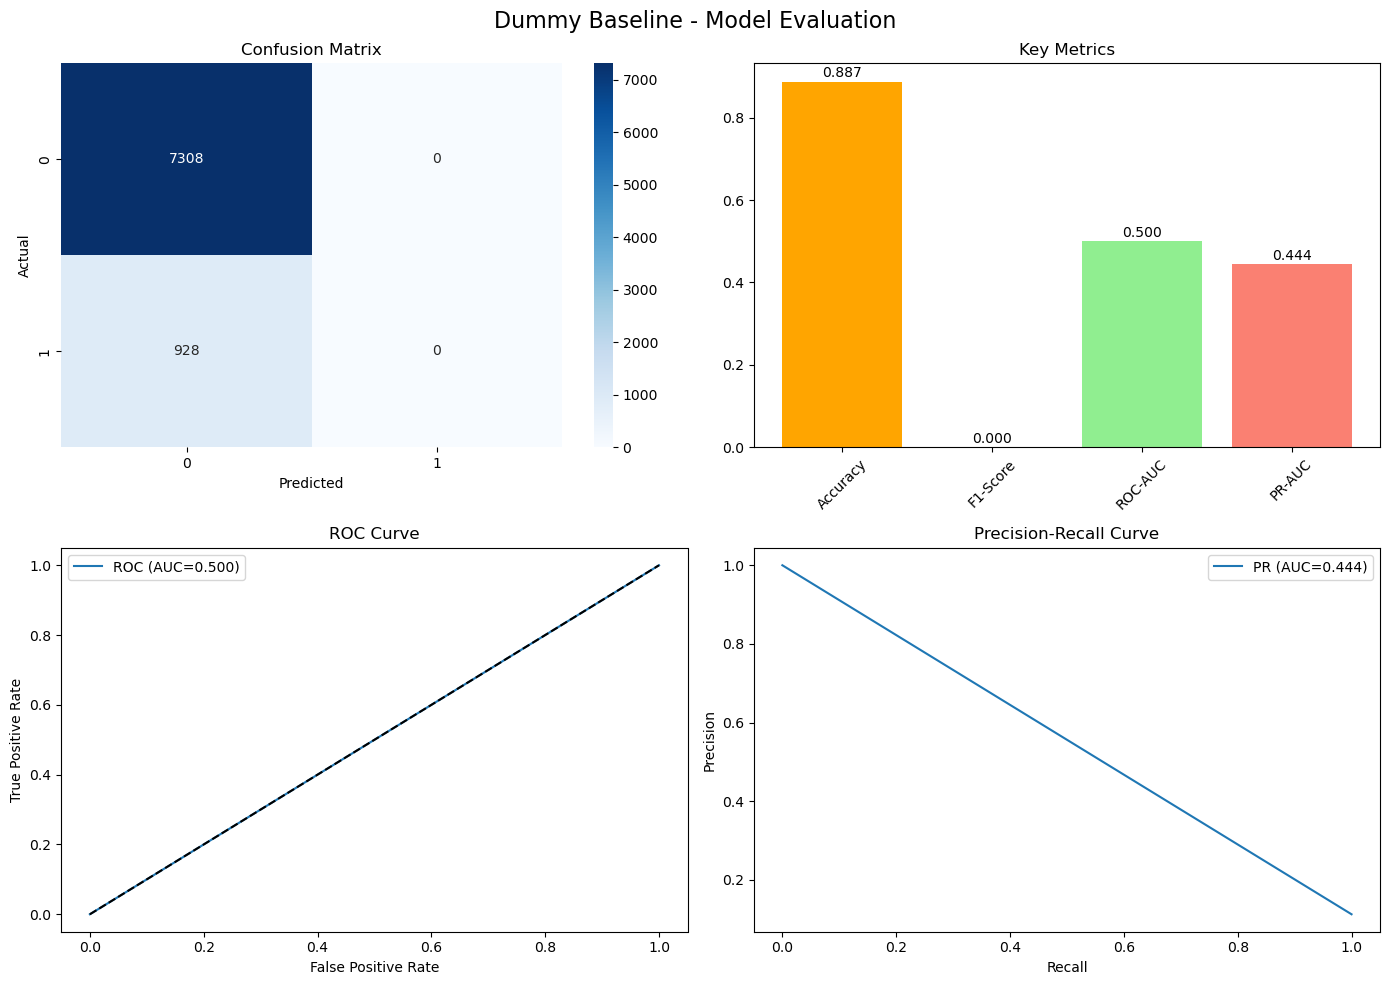

In [82]:
# 1. DUMMY BASELINE
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_results = evaluate_model(dummy_model, X_train_prep, y_train, X_test_prep, y_test, "Dummy Baseline")

#### Logistic Regression with defualt parameters


Evaluating Logistic Regression Default...
Training Time: 0.3426 seconds

Accuracy: 0.8299
F1 Score: 0.4605

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7308
           1       0.36      0.64      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236

ROC-AUC: 0.7995
PR-AUC: 0.3315
Precision: 0.3583
Recall (Sensitivity): 0.6444
Specificity: 0.8534
Balanced Accuracy: 0.7489


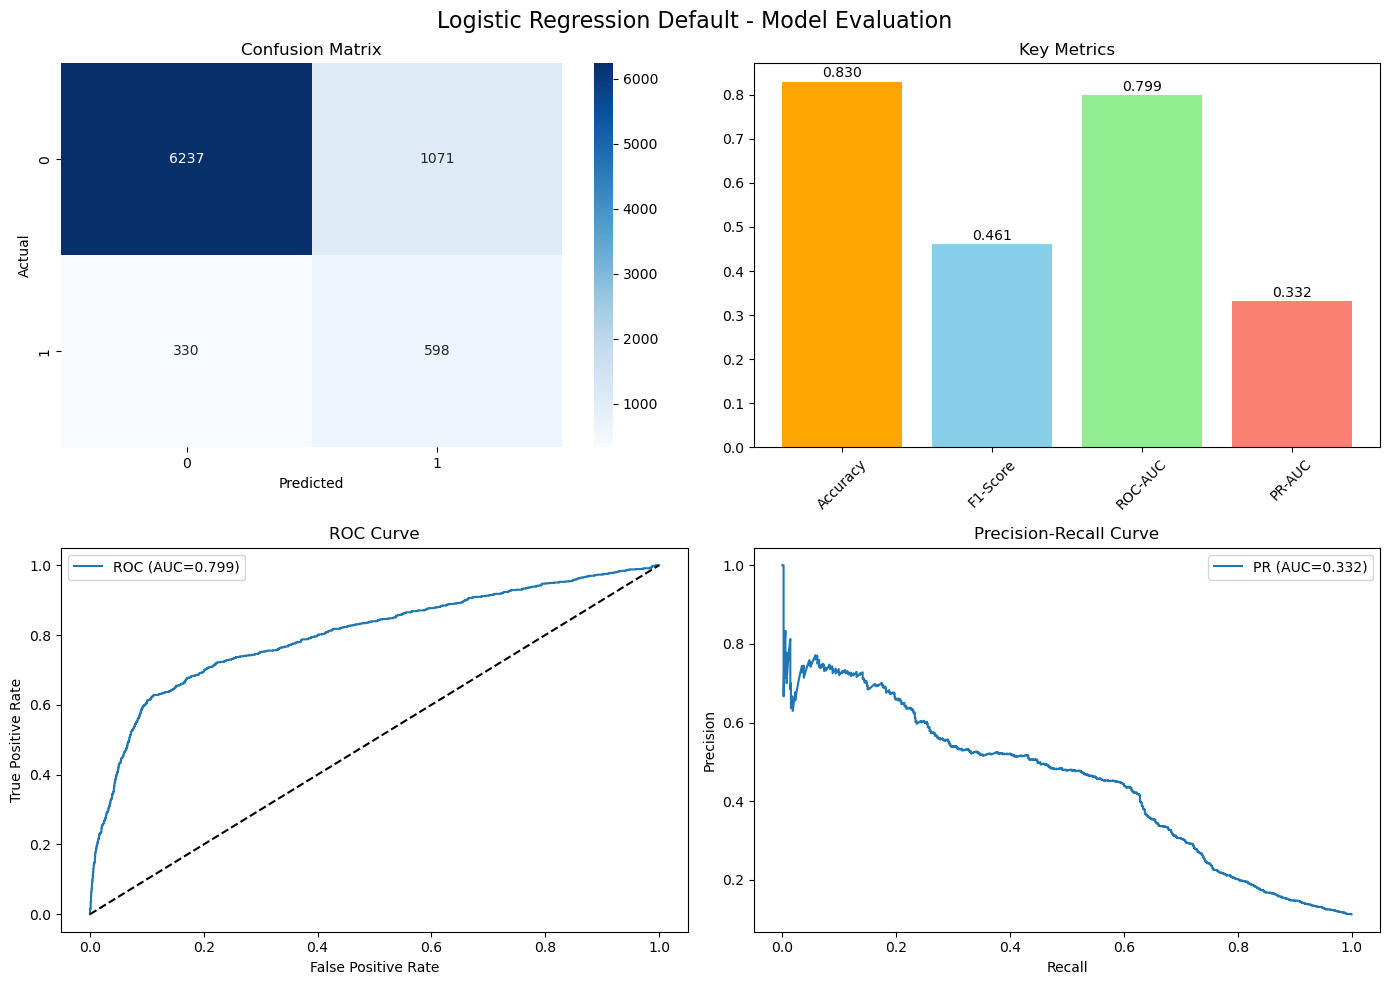

In [83]:
# 2. LOGISTIC REGRESSION
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_results = evaluate_model(lr_model, X_train_prep, y_train, X_test_prep, y_test, "Logistic Regression Default")

#### KNN with default parameters


Evaluating KNN  Default...
Training Time: 0.0033 seconds

Accuracy: 0.8941
F1 Score: 0.3894

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7308
           1       0.56      0.30      0.39       928

    accuracy                           0.89      8236
   macro avg       0.74      0.63      0.67      8236
weighted avg       0.88      0.89      0.88      8236

ROC-AUC: 0.7402
PR-AUC: 0.2949
Precision: 0.5560
Recall (Sensitivity): 0.2996
Specificity: 0.9696
Balanced Accuracy: 0.6346


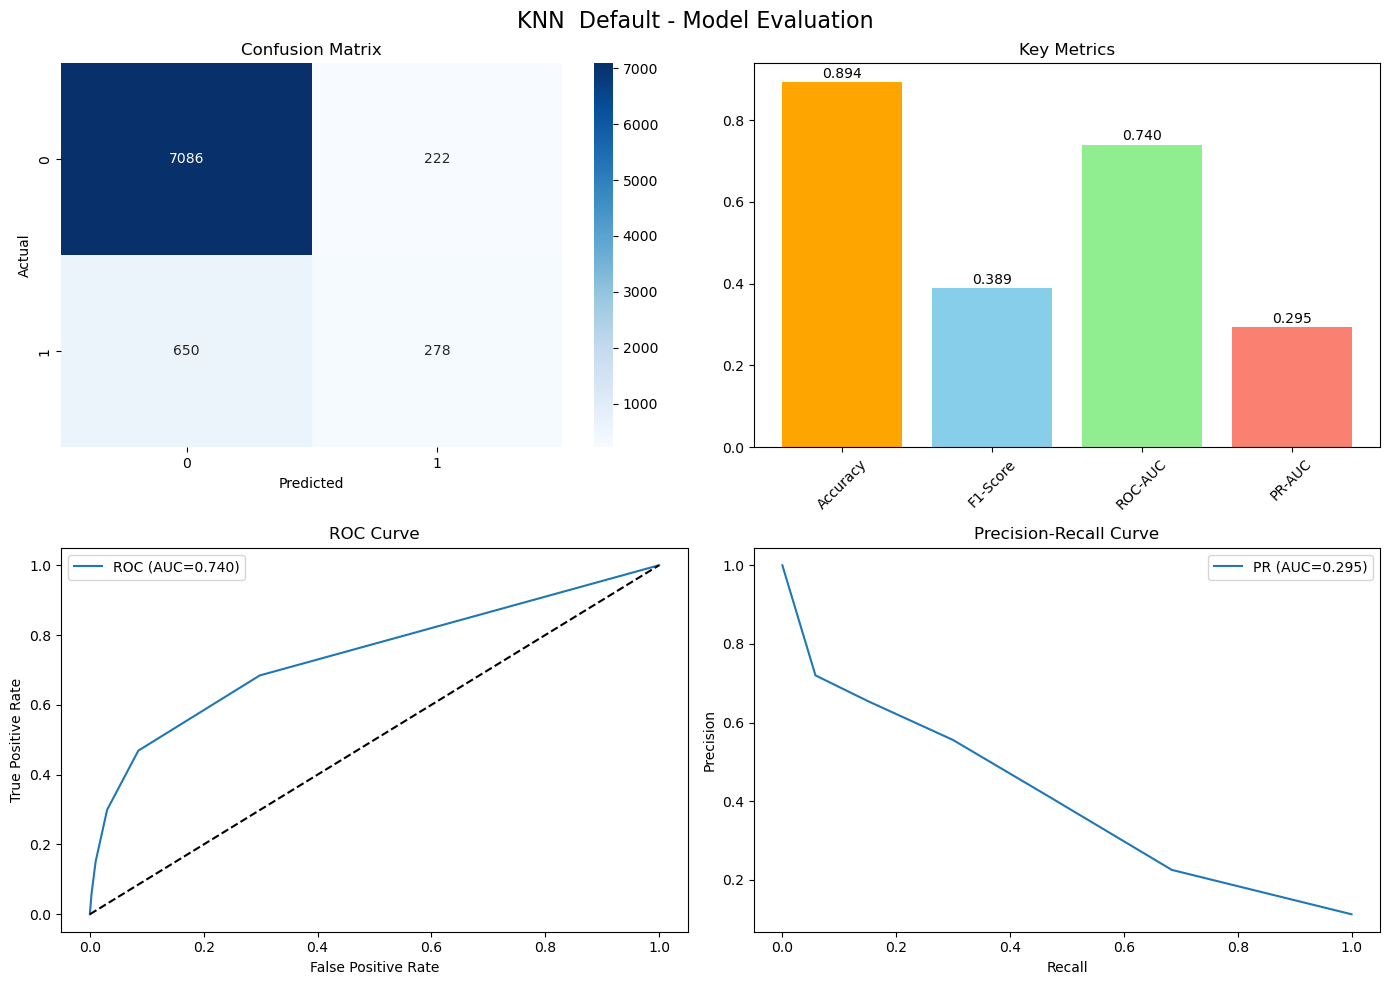

In [84]:
# 3. KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results = evaluate_model(knn_model, X_train_prep, y_train, X_test_prep, y_test, "KNN  Default")

#### Decision Tree with default parameters


Evaluating Decision Tree  Default...
Training Time: 0.2792 seconds

Accuracy: 0.8479
F1 Score: 0.3360

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7308
           1       0.33      0.34      0.34       928

    accuracy                           0.85      8236
   macro avg       0.62      0.63      0.63      8236
weighted avg       0.85      0.85      0.85      8236

ROC-AUC: 0.6275
PR-AUC: 0.2581
Precision: 0.3306
Recall (Sensitivity): 0.3416
Specificity: 0.9122
Balanced Accuracy: 0.6269


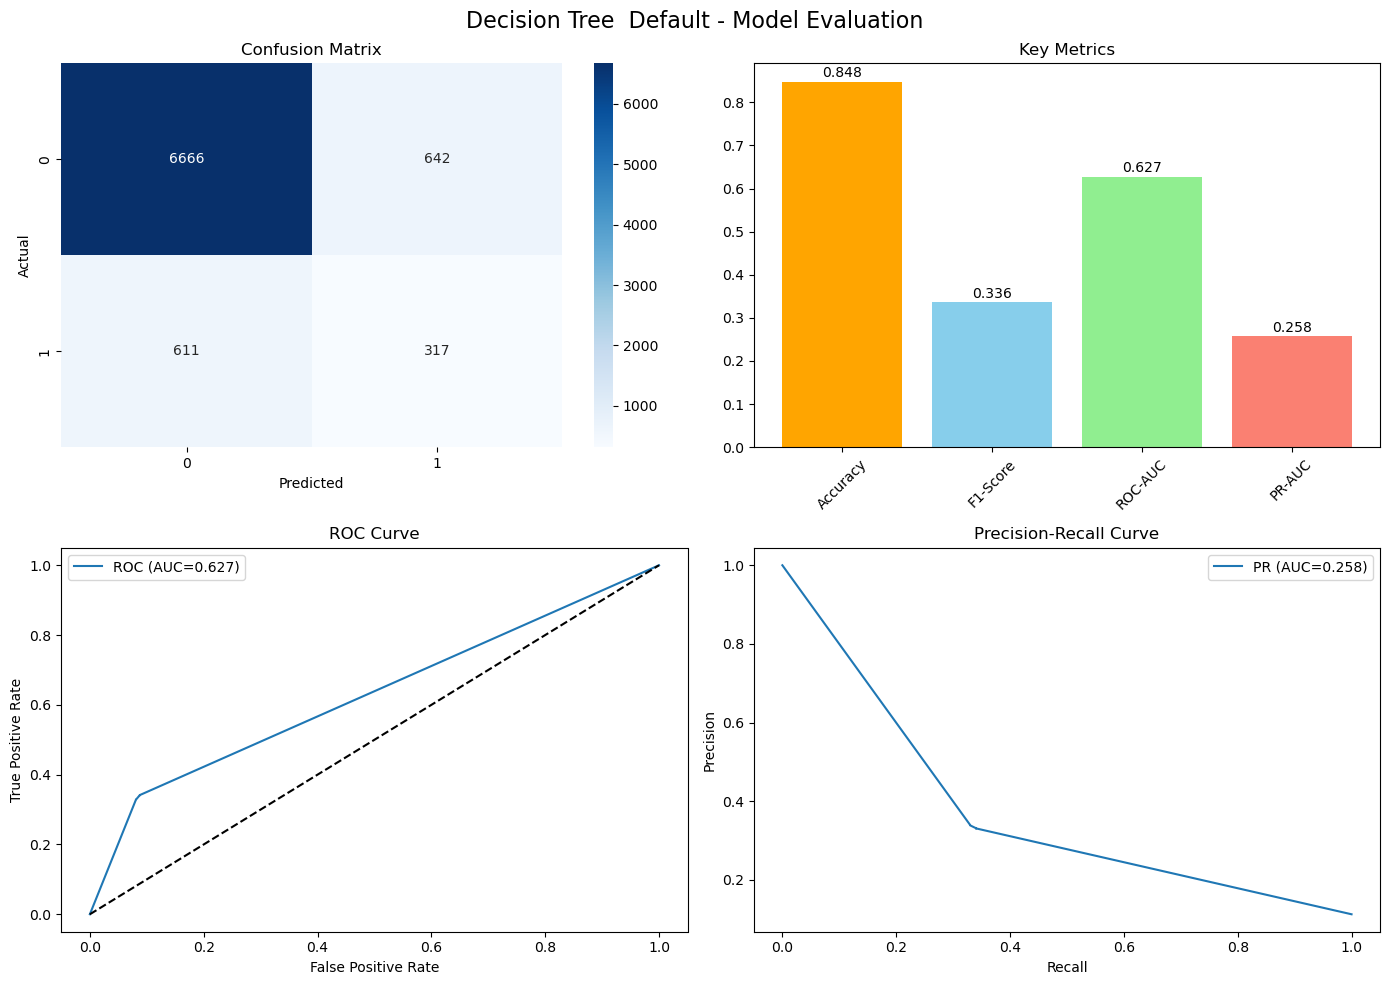

In [85]:
# 4. DECISION TREE with default parameters
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_results = evaluate_model(dt_model, X_train_prep, y_train, X_test_prep, y_test, "Decision Tree  Default")

#### SVM LINEAR with default parameters

In [86]:
# 5. SVM LINEAR with default parameters
# svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42, probability=True)
# svm_results = evaluate_model(svm_model, X_train_prep, y_train, X_test_prep, y_test, "SVM Linear Default")

#### Key Points

* Created a **generic model evaluation function** with metrics and visualizations for consistent performance assessment.

* Tested **baseline dummy classifiers** to establish a reference point for comparison.

* Built **Logistic Regression, KNN, Decision Tree, and Linear SVM** using default parameters for initial benchmarking.

* Observed that **SVM with RBF or full linear kernel** is too slow for real-time deployment in banking scenarios.

* Applied **class_weight='balanced'** where possible to automatically account for the 88.7:11.3 class imbalance.


### 4.4 Assess Model(No Tuning)

#### Model Assessment Results (Default Hyperparameters)

In [87]:
# SUMMARY TABLE
all_results = {
    'Dummy Baseline': dummy_results,
    'Logistic Regression': lr_results,
    'KNN': knn_results,
    'Decision Tree': dt_results,
    'SVM Linear': svm_results
}

keys_to_remove = ['confusion_matrix', 'y_pred', 'y_pred_proba', 'true_positives', 
                 'false_positives', 'true_negatives', 'false_negatives']

summary_df = pd.DataFrame(all_results).T
summary_df = summary_df.drop(columns=keys_to_remove)
summary_df

NameError: name 'svm_results' is not defined

#### Key Findings

Below is a technical assessment of the models based strictly on evaluation metrics. No parameter tuning or refinement is considered at this stage.

**Dummy Baseline**   
Not a usable model. It predicts only the majority class and completely fails to detect subscribers. Serves only as a reference point.

**Logistic Regression**  
Strong overall performer. Best ROC-AUC and good balance between recall and specificity. Captures a majority of positive cases while maintaining reasonable false positives. Technically the most robust and stable model.

**KNN**  
High overall accuracy but poor recall. Misses many positive cases (high false negatives). Not ideal when identifying subscribers is important.

**Decision Tree**   
Moderate accuracy but weaker discriminative ability. Lower AUC and F1 indicate poorer separation between classes compared to other models.

**Linear SVM**   
Performance comparable to Logistic Regression, with similar F1 and recall. However, computational cost is significantly higher, which may limit scalability.

Overall Ranking (Based on Predictive Quality)

1. **Logistic Regression** – Best overall balance (highest ROC-AUC, strong recall, stable performance)
2. **Linear SVM** – Similar predictive power but computationally expensive
3. **KNN** – High accuracy but weak recall
4. **Decision Tree** – Moderate performance
5. **Dummy Baseline** – Not suitable


Logistic Regression currently provides the best trade-off between discrimination ability, recall of positive cases, and overall stability. It outperforms other models on ROC-AUC and balanced accuracy, making it the strongest candidate at this stage of assessment.


### 4.5 Build Model With Tuning

#### Generic function to tune, evaluate and visualize models

In [ ]:
def tune_model(model, param_grid, X_train, y_train, X_test, y_test, model_name, 
               cv=5, scoring='f1', n_jobs=-1, visualize=True):
    """
    Generic function to GridSearchCV tune ANY model, evaluate best model, and visualize.
    
    Args:
        model: Unfitted sklearn model
        param_grid: dict of parameters to tune
        X_train, y_train, X_test, y_test: data
        model_name: str for display
        cv, scoring, n_jobs: GridSearchCV params
        visualize: bool to show plots
    """
    
    print(f"\n{'='*60}")
    print(f"{model_name}...")
    print('='*60)
    
    # GridSearchCV (skip if empty param_grid)
    if param_grid:
        grid_search = GridSearchCV(
            model, param_grid, 
            cv=cv, scoring=scoring, 
            n_jobs=n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f"Best params: {grid_search.best_params_}")
        print(f"Best CV {scoring}: {grid_search.best_score_:.4f}")
        best_params = grid_search.best_params_
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = 'N/A'
    
    # Evaluate best model
    result = evaluate_model(
        best_model, X_train, y_train, X_test, y_test, 
        f"{model_name} (Tuned)", visualize=visualize
    )
    result['best_params'] = best_params
    
    return result

#### Logistic Regression with hyperparameter tuning


Logistic Regression with tuning...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV f1: 0.4519

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7308
           1       0.36      0.64      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



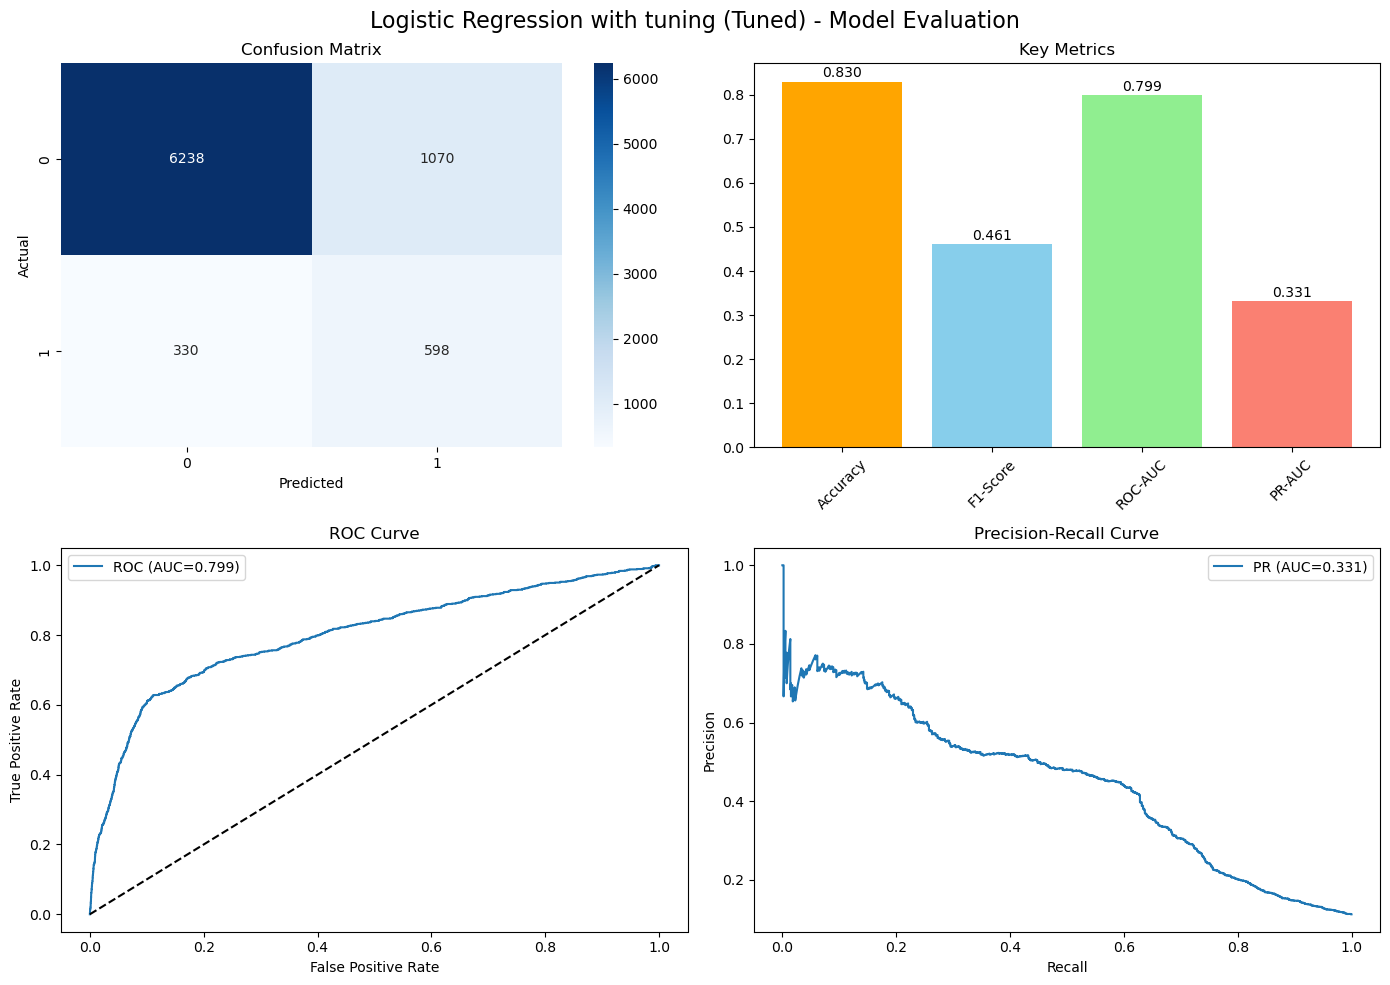

In [ ]:
# Logistic Regression with hyperparameter tuning
lr_result_tuned = tune_model(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid={
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    X_train=X_train_prep, y_train=y_train, X_test=X_test_prep, y_test=y_test,
    model_name="Logistic Regression with tuning",
    visualize=True
)

#### KNN with hyperparameter tuning


KNN  with tuning...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV f1: 0.3793

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7308
           1       0.56      0.30      0.39       928

    accuracy                           0.89      8236
   macro avg       0.74      0.63      0.67      8236
weighted avg       0.88      0.89      0.88      8236



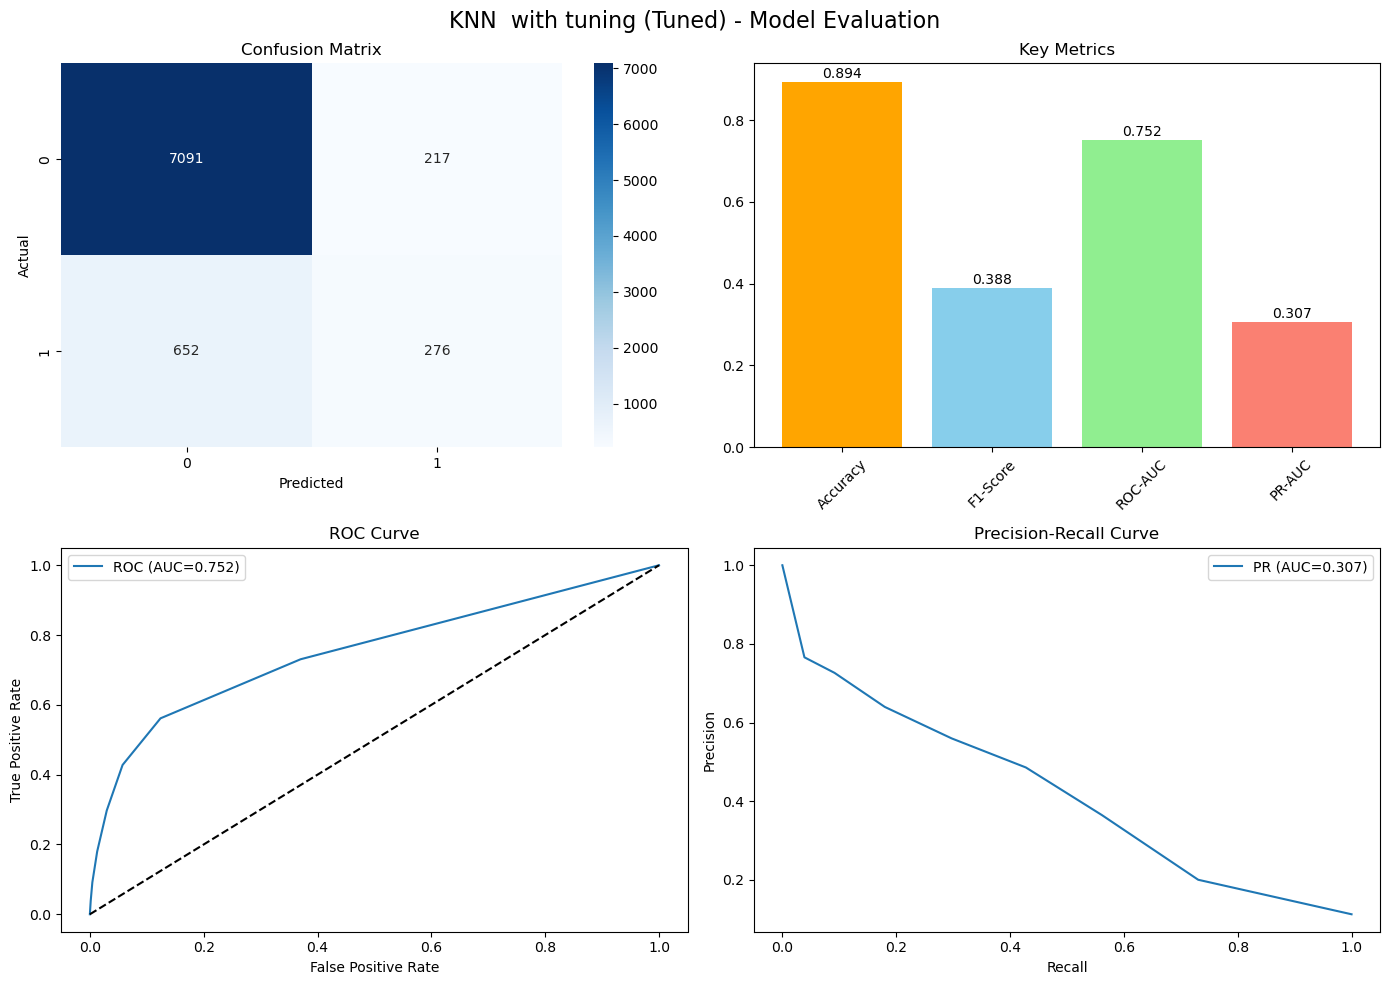

In [ ]:
# KNN with hyperparameter tuning
knn_result_tuned = tune_model(
    KNeighborsClassifier(),
    param_grid={
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    X_train=X_train_prep, y_train=y_train, X_test=X_test_prep, y_test=y_test,
    model_name="KNN  with tuning",
    visualize=True
)

#### Decision Tree with hyperparameter tuning


Decision Tree with tuning...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV f1: 0.3786

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7308
           1       0.62      0.27      0.37       928

    accuracy                           0.90      8236
   macro avg       0.76      0.62      0.66      8236
weighted avg       0.88      0.90      0.88      8236



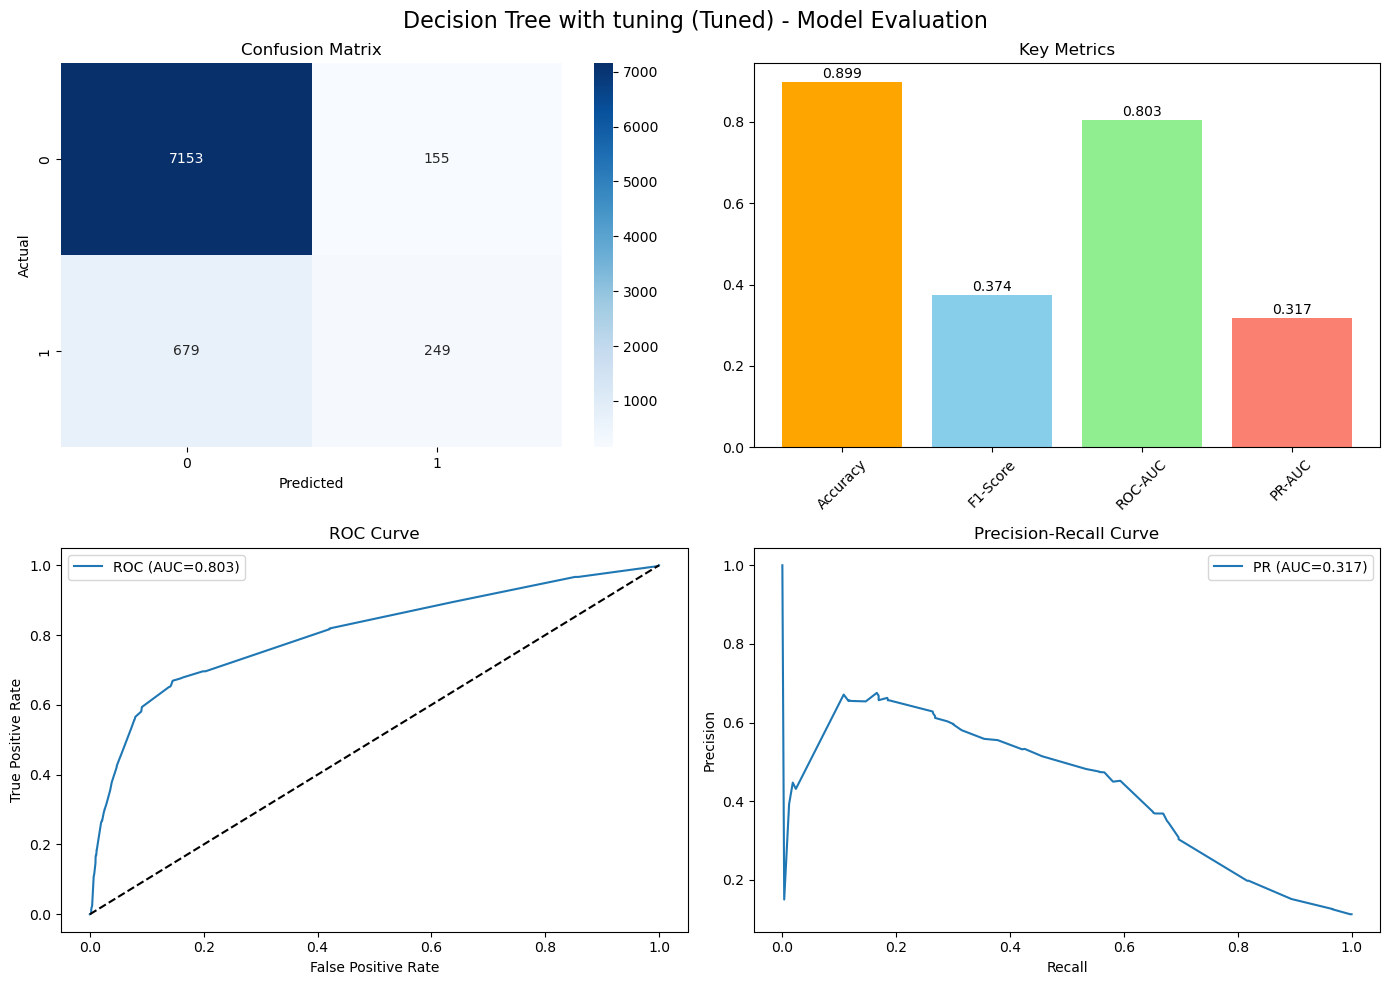

In [ ]:
# Decision Tree with hyperparameter tuning
dt_result_tuned = tune_model(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid={
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    X_train=X_train_prep, y_train=y_train, X_test=X_test_prep, y_test=y_test,
    model_name="Decision Tree with tuning",
    visualize=True
)

#### SVM Linear with hyperparameter tuning


SVM Linear with tuning(Fast)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'C': 0.1, 'gamma': 'scale'}
Best CV f1: 0.2877

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7308
           1       0.61      0.20      0.30       928

    accuracy                           0.90      8236
   macro avg       0.76      0.59      0.62      8236
weighted avg       0.87      0.90      0.87      8236



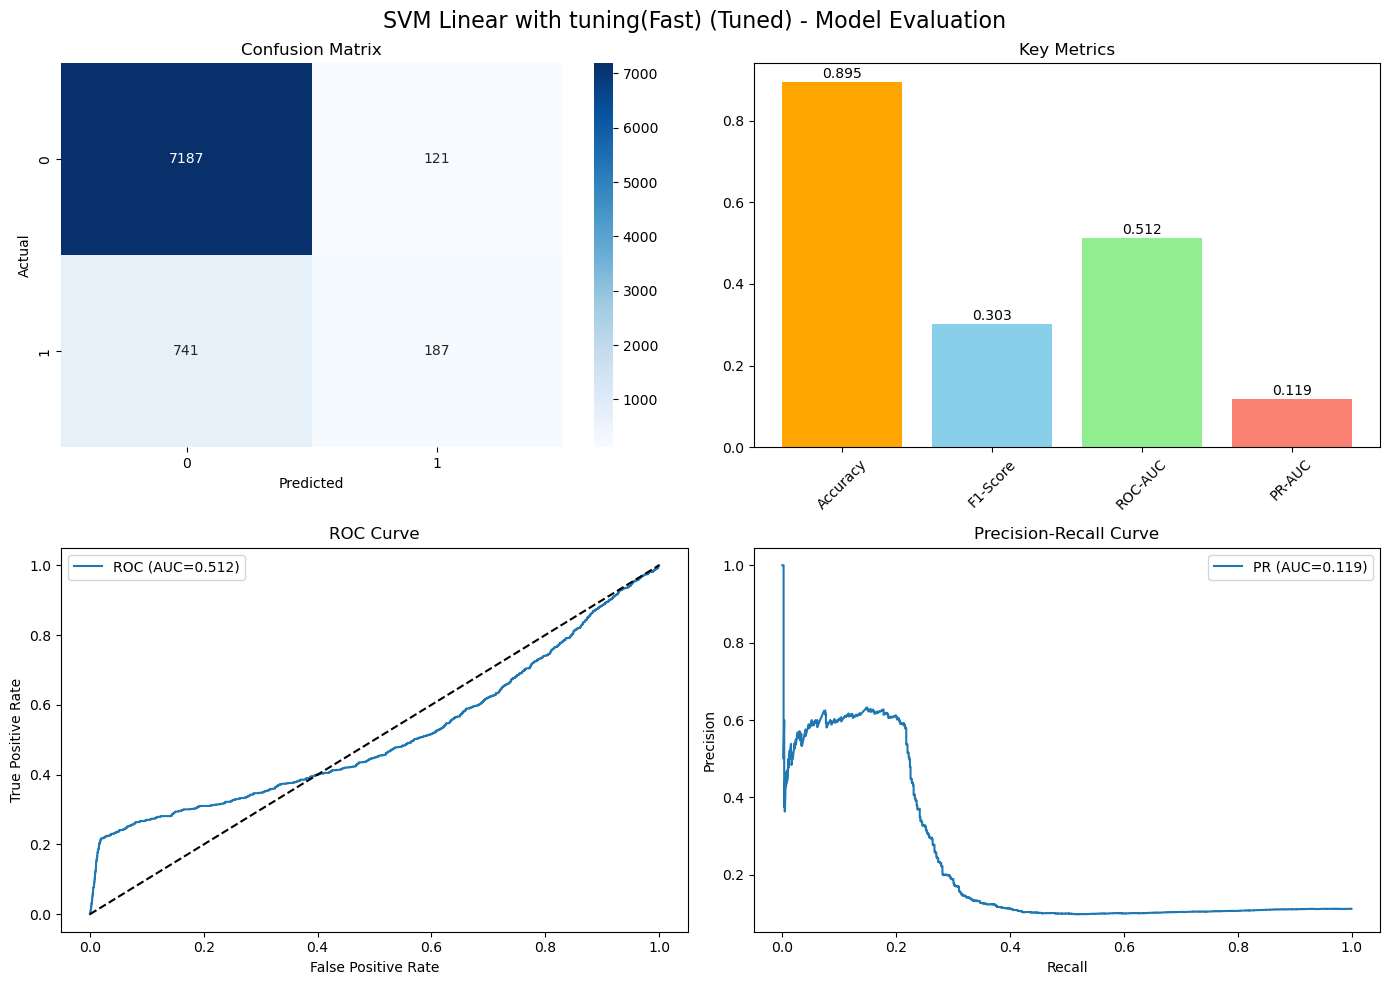

In [ ]:
# SVM Linear with hyperparameter tuning

# Sample 25% of data for SVM (both X and y are NumPy arrays)
n_samples = int(0.25 * X_train_prep.shape[0])
svm_idx = np.random.choice(X_train_prep.shape[0], size=n_samples, replace=False)

X_train_svm = X_train_prep[svm_idx]    # NumPy array indexing
y_train_svm = y_train[svm_idx]         # NumPy array indexing

svm_result_tuned = tune_model(
    SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42),  # No probability=True
    param_grid={
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    },
    X_train=X_train_svm, 
    y_train=y_train_svm, 
    X_test=X_test_prep, 
    y_test=y_test,
    model_name="SVM Linear with tuning(Fast)",
    cv=3,
    visualize=True
)


##### Key points

* Developed a **generic model tuning function** to streamline training, evaluation, and comparison across models.

* Built **Logistic Regression, KNN, Decision Tree** with hyper parameter tuning.

* **Linear SVM** was tuned with `C = [0.1, 1, 10]` using a 25% random subsample (~11K rows) and 3-fold GridSearchCV to optimize F1 score.

* Full RBF or linear SVM on all data with 5-fold CV was too slow, confirming that **linear kernel with subsampling** is more practical for this dataset.


### 4.6 Assess Results With Tuning

#### Model Assessment Results With hyperparameter Tuning

In [ ]:
all_results_tuned = {
    'Logistic Regression': lr_result_tuned,
    'KNN': knn_result_tuned,
    'Decision Tree': dt_result_tuned,
    'SVM Linear': svm_result_tuned
}

keys_to_remove = ['confusion_matrix', 'y_pred', 'y_pred_proba', 'true_positives', 
                 'false_positives', 'true_negatives', 'false_negatives']

comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df.drop(columns=keys_to_remove, errors='ignore')
comparison_df['best_params'] = [r.get('best_params', 'N/A') for r in all_results.values()]

print("\n" + "="*80)
print("FINAL MODEL COMPARISON (Tuned)")
print("="*80)
print(comparison_df.round(4))

#### Model assessment combined with default parameters and with hyperparameter tuning

In [ ]:
comparison_df = comparison_df.drop(columns=['best_params'], errors='ignore')
final_df = summary_df + comparison_df

final_df

#### Key findings

## 5.Evaluation

### 5.1 Evaluate results

### 5.2 Review process

### 5.3 Next steps

## 6. Deployment

### 6.1 Deployment Strategy

### 6.2 Monitoring and Maintenance

### 6.3 Final Report

### 6.4 Review project

## Other

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

### Problem 9: Score the Model

What is the accuracy of your model?

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric